# 03 - Segmentation et d?tection de l?objet

Dans cette ?tape, nous allons segmenter la voiture sans utiliser le groundtruth comme m?thode principale. Nous allons comparer deux m?thodes de seuillage : Otsu et le seuillage adaptatif. Ensuite, nous choisissons le meilleur masque pour d?tecter les points caract?ristiques de la voiture.


## 1. Introduction

La segmentation permet d?isoler approximativement la voiture. Nous comparons Otsu et Adaptive Threshold. Le groundtruth n?est pas utilis? ici pour suivre la voiture. Il sera utilis? seulement pour comparaison.


## 2. Importation des biblioth?ques


In [1]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append("../")

from src.detection import (
    read_groundtruth, extract_roi, preprocess_roi, segment_otsu,
    segment_adaptive, clean_mask, detect_canny,
    detect_features_in_mask, compare_masks,
)

plt.rcParams["figure.figsize"] = (12, 6)

def show_bgr(image, title):
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(image, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def count_points(points):
    return 0 if points is None else len(points)

def draw_points_on_roi(roi_bgr, points):
    out = roi_bgr.copy()
    if points is not None:
        for p in points.reshape(-1, 2):
            px, py = p.astype(int)
            cv2.circle(out, (px, py), 3, (0, 0, 255), -1)
    return out


## 3. Chargement de la premi?re frame

Nous chargeons la premi?re image du dataset et nous affichons l?image originale.


Nombre d'images : 1661


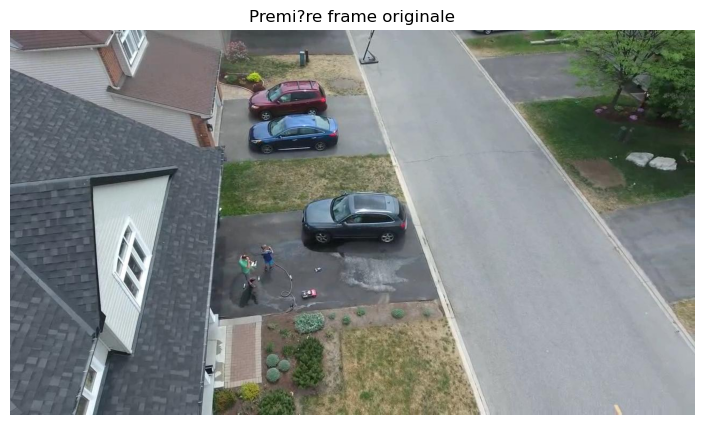

In [2]:
dataset_path = Path("../data/car/car-11")
img_path = dataset_path / "img"
groundtruth_path = dataset_path / "groundtruth.txt"
results_path = Path("../results")
plots_path = results_path / "plots"
results_path.mkdir(parents=True, exist_ok=True)
plots_path.mkdir(parents=True, exist_ok=True)

image_files = sorted([p for p in img_path.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
first_image_bgr = cv2.imread(str(image_files[0]))
print("Nombre d'images :", len(image_files))
show_bgr(first_image_bgr, "Premi?re frame originale")


## 4. D?finition d?une ROI manuelle

Cette bbox est d?finie manuellement apr?s observation de la premi?re image. Elle ne vient pas de `groundtruth.txt`.

Nous utilisons cette ROI manuelle seulement pour limiter la zone de segmentation autour de la voiture. Le groundtruth n?est pas utilis? pour cette ?tape.


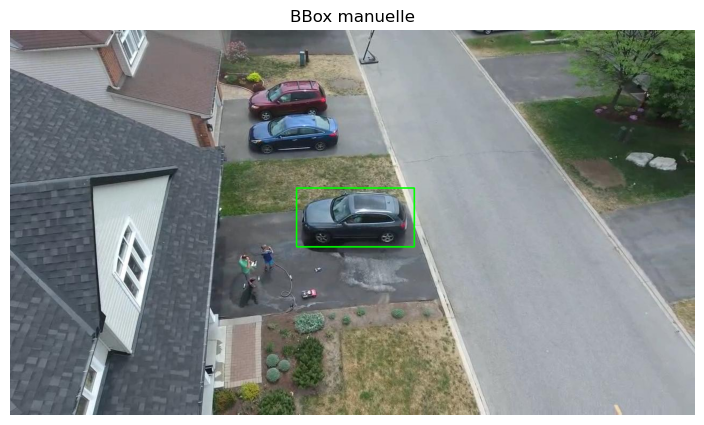

In [3]:
manual_bbox = (535, 295, 220, 110)  # x, y, w, h
x, y, w, h = manual_bbox
image_bbox = first_image_bgr.copy()
cv2.rectangle(image_bbox, (x, y), (x + w, y + h), (0, 255, 0), 2)
show_bgr(image_bbox, "BBox manuelle")


## 5. Pr?traitement de la ROI

Nous avons appliqu? grayscale, CLAHE avec `clipLimit=2.0` et `tileGridSize=(8,8)`, puis GaussianBlur avec un kernel `(5,5)`. Cette ?tape permet de pr?parer l?image pour le seuillage et de r?duire le bruit.


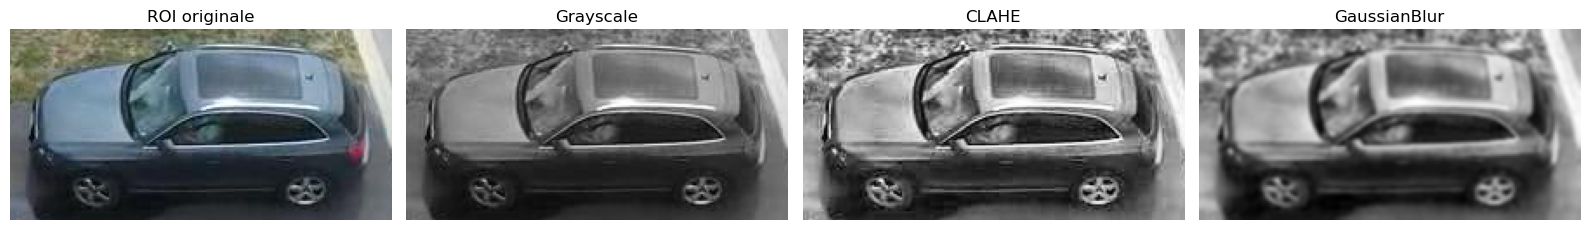

In [4]:
roi_bgr = extract_roi(first_image_bgr, manual_bbox)
gray_roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
roi_clahe = clahe.apply(gray_roi)
preprocessed_roi = cv2.GaussianBlur(roi_clahe, (5, 5), 0)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
items = [(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB), "ROI originale", None), (gray_roi, "Grayscale", "gray"), (roi_clahe, "CLAHE", "gray"), (preprocessed_roi, "GaussianBlur", "gray")]
for ax, (im, title, cmap) in zip(axes, items):
    ax.imshow(im, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Segmentation par Otsu

Otsu choisit automatiquement un seuil global. Cette m?thode est simple et efficace lorsque l?objet et le fond ont des intensit?s bien s?par?es.


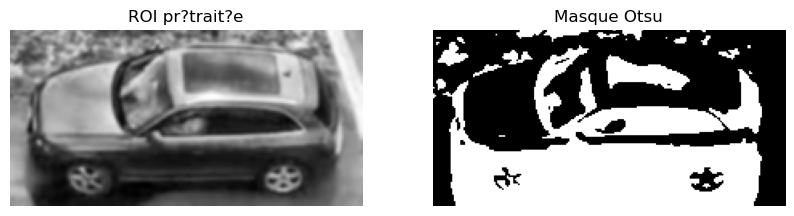

In [5]:
_, mask_otsu = cv2.threshold(preprocessed_roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(preprocessed_roi, cmap="gray"); axes[0].set_title("ROI pr?trait?e")
axes[1].imshow(mask_otsu, cmap="gray"); axes[1].set_title("Masque Otsu")
for ax in axes: ax.axis("off")
plt.show()


## 7. Segmentation par seuillage adaptatif

Le seuillage adaptatif calcule un seuil local pour chaque zone de l?image. Il est plus adapt? lorsque l??clairage varie ou lorsque l?objet et le fond ont des intensit?s proches.

`blockSize=31` donne un voisinage local assez large. `C=5` ajuste la sensibilit? du seuil. `THRESH_BINARY_INV` est utilis? car la voiture est plus sombre que le fond.


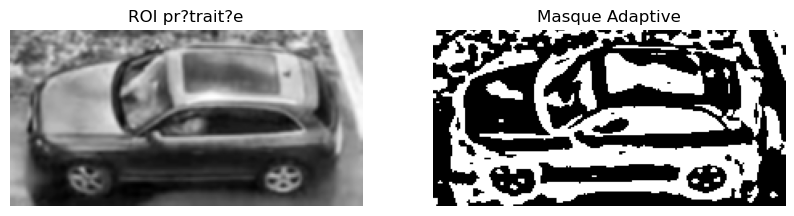

In [6]:
mask_adaptive = cv2.adaptiveThreshold(preprocessed_roi, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, blockSize=31, C=5)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(preprocessed_roi, cmap="gray"); axes[0].set_title("ROI pr?trait?e")
axes[1].imshow(mask_adaptive, cmap="gray"); axes[1].set_title("Masque Adaptive")
for ax in axes: ax.axis("off")
plt.show()


## 8. Nettoyage morphologique des masques

Nous utilisons un kernel `(5,5)`. Le closing avec 2 it?rations ferme les petits trous. L?opening avec 1 it?ration supprime les petits bruits. C?est un compromis simple.


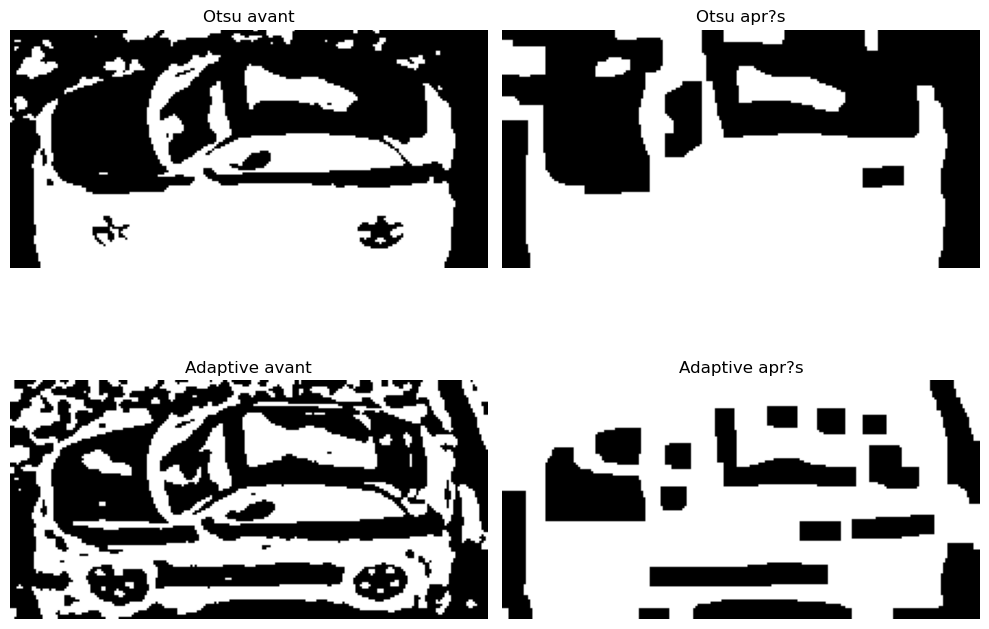

In [7]:
kernel = np.ones((5, 5), np.uint8)
mask_otsu_clean = cv2.morphologyEx(mask_otsu, cv2.MORPH_CLOSE, kernel, iterations=2)
mask_otsu_clean = cv2.morphologyEx(mask_otsu_clean, cv2.MORPH_OPEN, kernel, iterations=1)
mask_adaptive_clean = cv2.morphologyEx(mask_adaptive, cv2.MORPH_CLOSE, kernel, iterations=2)
mask_adaptive_clean = cv2.morphologyEx(mask_adaptive_clean, cv2.MORPH_OPEN, kernel, iterations=1)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, im, title in zip(axes.ravel(), [mask_otsu, mask_otsu_clean, mask_adaptive, mask_adaptive_clean], ["Otsu avant", "Otsu apr?s", "Adaptive avant", "Adaptive apr?s"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 9. Comparaison Otsu vs Adaptive

Nous observons quel masque contient moins de bruit, quel masque isole mieux la voiture et quel masque semble plus utile pour d?tecter des points.


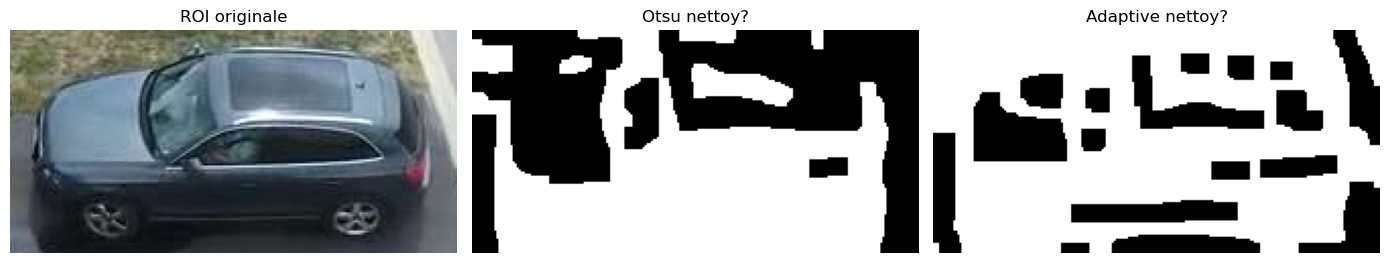

Aire Otsu : 0.5363636363636364
Aire Adaptive : 0.6980578512396695


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)); axes[0].set_title("ROI originale")
axes[1].imshow(mask_otsu_clean, cmap="gray"); axes[1].set_title("Otsu nettoy?")
axes[2].imshow(mask_adaptive_clean, cmap="gray"); axes[2].set_title("Adaptive nettoy?")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.savefig(results_path / "segmentation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Aire Otsu :", cv2.countNonZero(mask_otsu_clean) / mask_otsu_clean.size)
print("Aire Adaptive :", cv2.countNonZero(mask_adaptive_clean) / mask_adaptive_clean.size)


## 10. D?tection des points caract?ristiques dans chaque masque

Le meilleur masque est celui qui permet de d?tecter un nombre suffisant de points sur la voiture, tout en ?vitant les points de l?arri?re-plan.

`maxCorners=80` ?vite de surcharger le suivi. `qualityLevel=0.01` garde assez de points. `minDistance=7` ?vite des points trop proches. `blockSize=7` donne un voisinage local stable.


Nombre de points avec Otsu : 80
Nombre de points avec Adaptive : 80


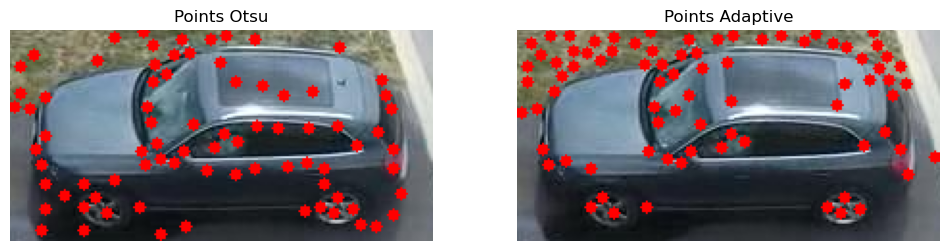

In [9]:
points_otsu = cv2.goodFeaturesToTrack(preprocessed_roi, maxCorners=80, qualityLevel=0.01, minDistance=7, blockSize=7, mask=mask_otsu_clean)
points_adaptive = cv2.goodFeaturesToTrack(preprocessed_roi, maxCorners=80, qualityLevel=0.01, minDistance=7, blockSize=7, mask=mask_adaptive_clean)
print("Nombre de points avec Otsu :", count_points(points_otsu))
print("Nombre de points avec Adaptive :", count_points(points_adaptive))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(draw_points_on_roi(roi_bgr, points_otsu), cv2.COLOR_BGR2RGB)); axes[0].set_title("Points Otsu")
axes[1].imshow(cv2.cvtColor(draw_points_on_roi(roi_bgr, points_adaptive), cv2.COLOR_BGR2RGB)); axes[1].set_title("Points Adaptive")
for ax in axes: ax.axis("off")
plt.show()


## 11. Choix du meilleur masque

Nous choisissons le masque qui isole le mieux la voiture et qui donne des points caract?ristiques exploitables pour Lucas-Kanade.


M?thode choisie : Otsu
Nombre de points d?tect?s : 80


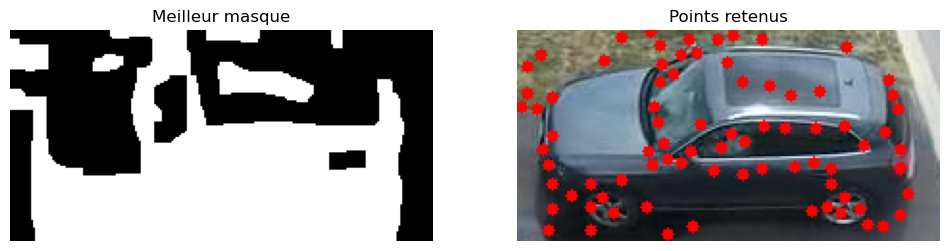

In [10]:
best_method_name = compare_masks(mask_otsu_clean, mask_adaptive_clean, points_otsu, points_adaptive)
if best_method_name == "Adaptive":
    best_mask = mask_adaptive_clean
    best_points = points_adaptive
else:
    best_mask = mask_otsu_clean
    best_points = points_otsu
print("M?thode choisie :", best_method_name)
print("Nombre de points d?tect?s :", count_points(best_points))
roi_best_points = draw_points_on_roi(roi_bgr, best_points)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(best_mask, cmap="gray"); axes[0].set_title("Meilleur masque")
axes[1].imshow(cv2.cvtColor(roi_best_points, cv2.COLOR_BGR2RGB)); axes[1].set_title("Points retenus")
for ax in axes: ax.axis("off")
plt.show()


## 12. D?tection des contours avec Canny

Canny est utilis? pour visualiser les contours de la voiture dans la zone segment?e. Il permet de v?rifier que le masque suit approximativement les fronti?res de l?objet.

`50` est le seuil bas et `150` le seuil haut. Les pixels entre les deux sont accept?s seulement s?ils sont connect?s ? un contour fort.


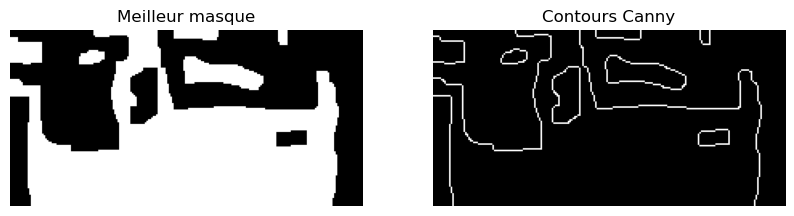

In [11]:
edges = cv2.Canny(best_mask, 50, 150)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(best_mask, cmap="gray"); axes[0].set_title("Meilleur masque")
axes[1].imshow(edges, cmap="gray"); axes[1].set_title("Contours Canny")
for ax in axes: ax.axis("off")
plt.show()


## 13. Comparaison avec groundtruth seulement pour v?rification

Le groundtruth n?est pas utilis? pour suivre l?objet. Il sert uniquement ? v?rifier visuellement la coh?rence de notre segmentation.


BBox manuelle : (535, 295, 220, 110)
BBox groundtruth premi?re frame : (543, 305, 202, 91)


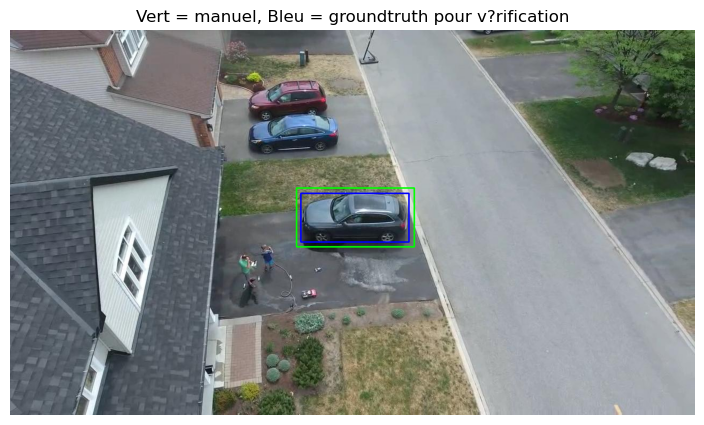

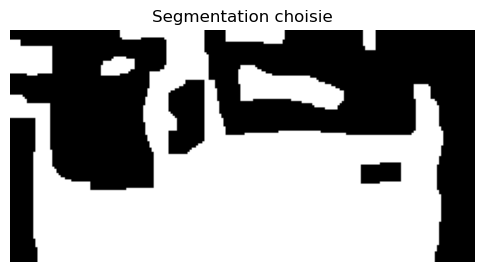

In [12]:
groundtruth = read_groundtruth(groundtruth_path)
verification = first_image_bgr.copy()
cv2.rectangle(verification, (x, y), (x + w, y + h), (0, 255, 0), 2)
if len(groundtruth) > 0:
    gt_x, gt_y, gt_w, gt_h = groundtruth.iloc[0].astype(int)
    cv2.rectangle(verification, (gt_x, gt_y), (gt_x + gt_w, gt_y + gt_h), (255, 0, 0), 2)
    print("BBox manuelle :", manual_bbox)
    print("BBox groundtruth premi?re frame :", (gt_x, gt_y, gt_w, gt_h))
show_bgr(verification, "Vert = manuel, Bleu = groundtruth pour v?rification")
show_gray(best_mask, "Segmentation choisie")


## 14. Sauvegarde des r?sultats de segmentation


In [13]:
cv2.imwrite(str(results_path / "initial_best_mask.png"), best_mask)
cv2.imwrite(str(results_path / "initial_canny_edges.png"), edges)
cv2.imwrite(str(results_path / "initial_points.png"), roi_best_points)
points_to_save = best_points if best_points is not None else np.empty((0, 1, 2), dtype=np.float32)
np.savez(results_path / "initialization_data.npz", manual_bbox=np.array(manual_bbox), best_mask=best_mask, best_points=points_to_save.astype(np.float32), best_method_name=np.array(best_method_name))
print("R?sultats sauvegard?s dans :", results_path)


R?sultats sauvegard?s dans : ..\results


## 15. Conclusion

Dans cette ?tape, nous avons r?alis? notre propre segmentation de la voiture. Nous avons compar? Otsu et le seuillage adaptatif, puis choisi le masque le plus adapt?. Ensuite, nous avons d?tect? les points caract?ristiques uniquement dans ce masque. Ces points seront utilis?s dans l??tape suivante par Lucas-Kanade pour estimer le mouvement.
